### Using the AUC results for direct regulons, perform statistical testing

In [11]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy.stats import ttest_ind, kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import os

In [33]:
plots_dir = "regulon_volcano_plots/"
os.makedirs(plots_dir, exist_ok=True)

In [34]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [12]:
def regulon_diff_test(df, group_col, comparison="sex"):
    ''' identify regulons that change by sex or age_group.'''
    results = []
    regulons = [c for c in df.columns if c not in ["Cell_type","sex","age_group"]]
    
    for reg in regulons:
        sub = df[[reg, group_col]].dropna()
        
        if comparison == "sex":  # two groups
            vals_m = sub[sub[group_col]=="male"][reg]
            vals_f = sub[sub[group_col]=="female"][reg]
            
            # fold change
            mean_m, mean_f = vals_m.mean(), vals_f.mean()
            log2fc = np.log2((mean_m+1e-9) / (mean_f+1e-9))
            
            # test
            stat, pval = mannwhitneyu(vals_m, vals_f,  alternative='two-sided')
        
        elif comparison == "age":  # 3 groups
            vals_o = sub[sub[group_col]=="old"][reg]
            vals_y = sub[sub[group_col]=="young"][reg]
            
            # fold change
            mean_o, mean_y = vals_o.mean(), vals_y.mean()
            log2fc = np.log2((mean_o+1e-9) / (mean_y+1e-9))
            
            # test
            stat, pval = ttest_ind(vals_o, vals_y, equal_var=False)
        
        results.append({
            "regulon": reg,
            "log2FC": log2fc,
            "pvalue": pval
        })
    
    res_df = pd.DataFrame(results)
    res_df["padj"] = multipletests(res_df["pvalue"], method="fdr_bh")[1]
    return res_df.sort_values("padj")

In [18]:
def plot_volcano(df, title, log2fc_col="log2FC", padj_col="padj", label_col="regulon",
                 fc_thresh=0.25, p_thresh=0.05, top_n=5, figsize=(8,6)):
    """
    Plot a volcano plot for differential analysis results.
    
    Parameters:
    - df: pd.DataFrame with at least log2FC and padj columns
    - log2fc_col: column name for log2 fold change
    - padj_col: column name for adjusted p-value
    - label_col: column name for labeling top hits
    - fc_thresh: fold-change threshold for significance
    - p_thresh: padj threshold for significance
    - top_n: number of top hits to label
    - figsize: matplotlib figure size
    """
    df = df.copy()
    df["neg_log10_padj"] = -np.log10(df[padj_col])
    
    # Significant points
    df["sig"] = (abs(df[log2fc_col]) > fc_thresh) & (df[padj_col] < p_thresh)
    
    # Assign color: red=up, blue=down, grey=ns
    df["color"] = "grey"
    df.loc[(df[log2fc_col] > fc_thresh) & (df[padj_col] < p_thresh), "color"] = "red"
    df.loc[(df[log2fc_col] < -fc_thresh) & (df[padj_col] < p_thresh), "color"] = "blue"
    
    plt.figure(figsize=figsize)
    sns.scatterplot(
        data=df,
        x=log2fc_col,
        y="neg_log10_padj",
        hue="color",
        palette={"red":"red","blue":"blue","grey":"grey"},
        edgecolor=None,
        alpha=0.7,
        legend=False
    )
    
    # Threshold lines
    plt.axhline(-np.log10(p_thresh), color="black", linestyle="--", lw=1)
    plt.axvline(fc_thresh, color="black", linestyle="--", lw=1)
    plt.axvline(-fc_thresh, color="black", linestyle="--", lw=1)
    
    # Annotate top hits

    sig_df = df[df["sig"]]
    for _, row in sig_df.nlargest(top_n, "neg_log10_padj").iterrows():
        plt.text(
            row[log2fc_col],
            row["neg_log10_padj"] + 0.5,
            row[label_col],
            ha="center",
            fontsize=6
        )
    
    plt.title(title)
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10(padj)")
    plt.tight_layout()
    plt.xlim(-2, 2)
    return plt

In [19]:
AUC_df = pd.read_csv("04A_regulon_AUC_df.csv", index_col = 0)

# keep only the direct (+/+)
AUC_df = AUC_df.loc[:, AUC_df.columns.str.contains("_direct_\\+/\\+")]

In [20]:
# split by colon first
split_cols = AUC_df.index.to_series().str.split(":", expand=True)

# first two columns
AUC_df["Cell_type"] = split_cols[0]
AUC_df["sex"] = split_cols[1]

# take only the first part before '_' for age_status
AUC_df["age_group"] = split_cols[2].str.split("_").str[0]

In [21]:
cell_types = AUC_df["Cell_type"].unique()

cell_types

array(['Cardiomyocyte', 'Endothelial', 'Fibroblast', 'Myeloid',
       'Pericyte'], dtype=object)

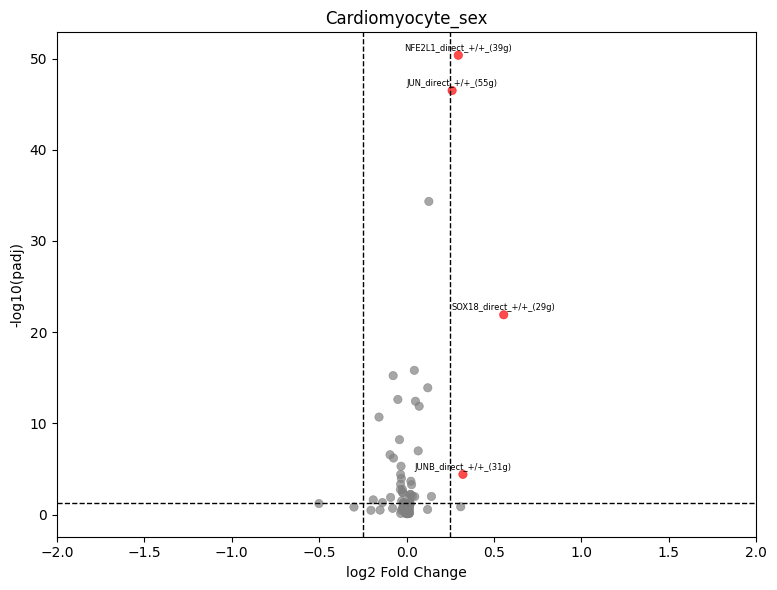

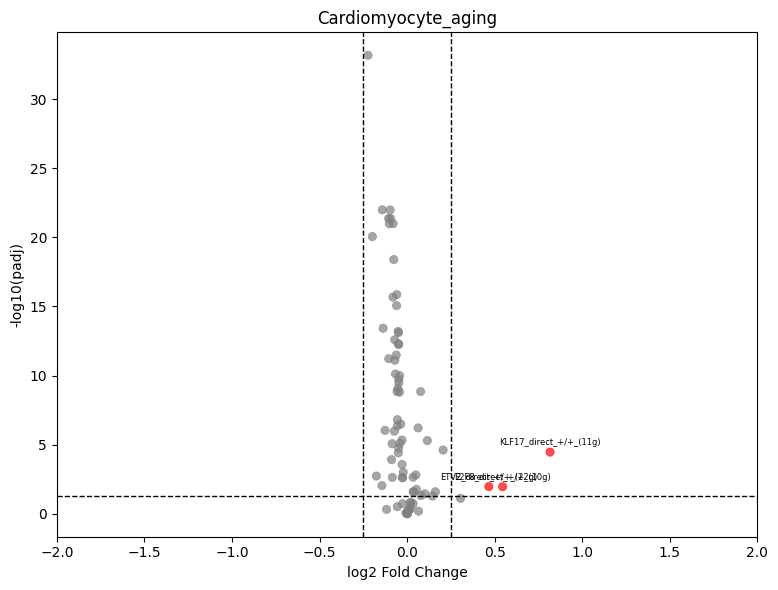

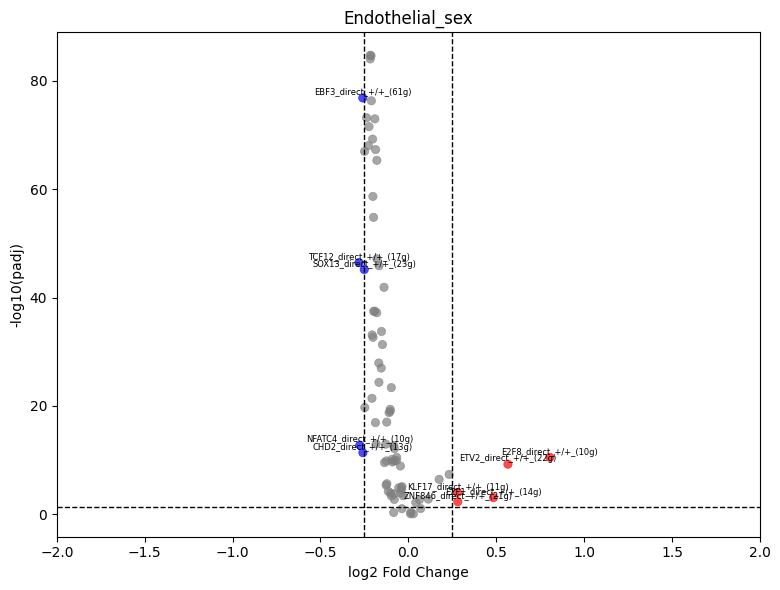

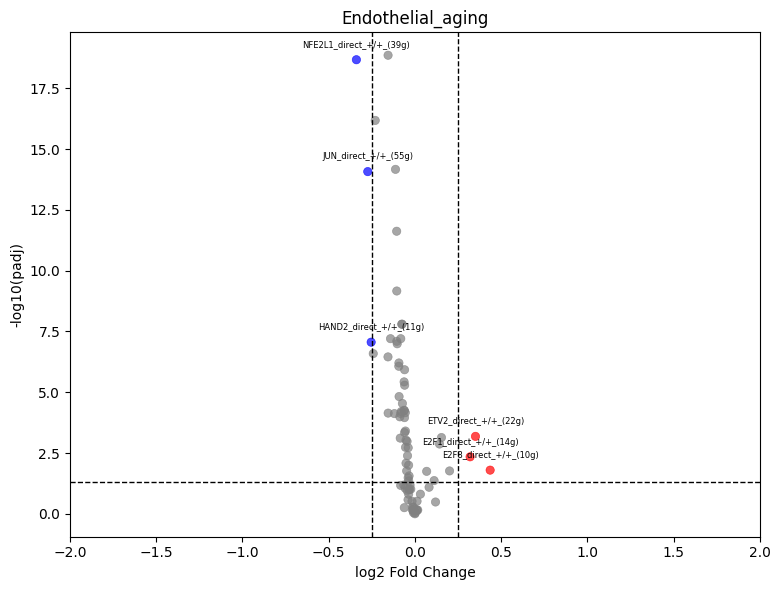

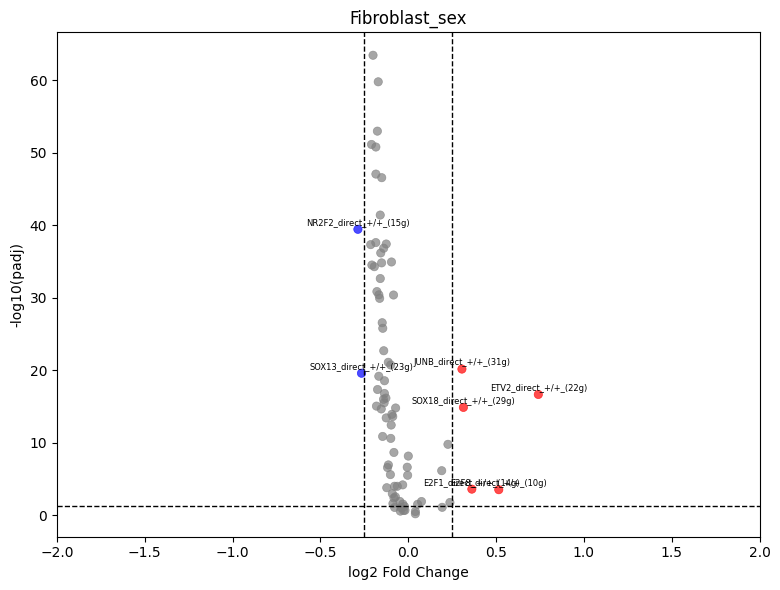

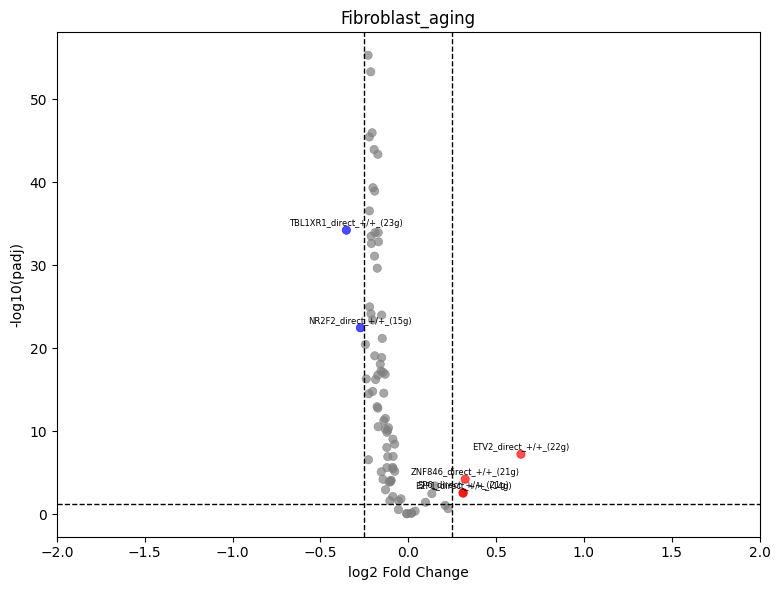

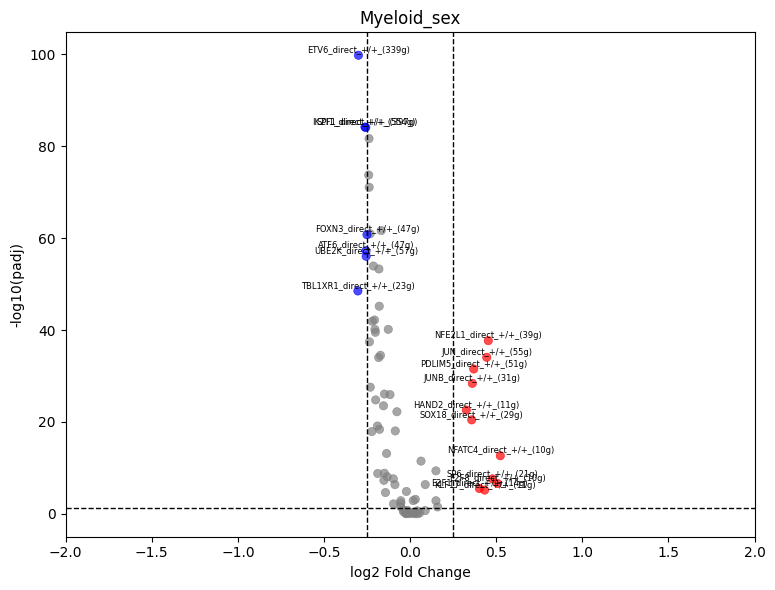

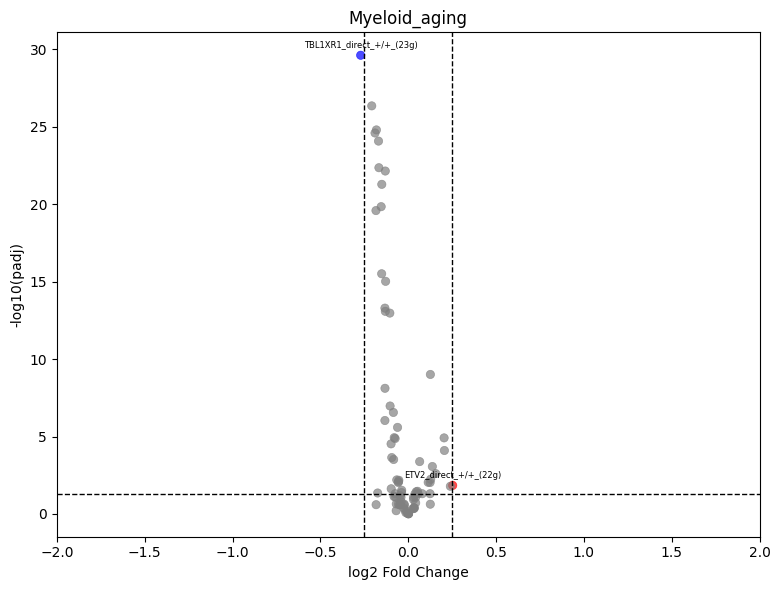

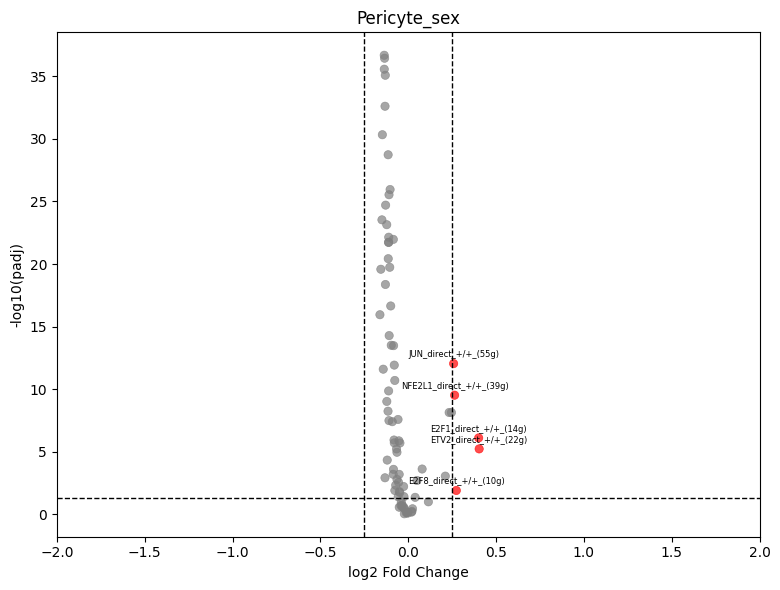

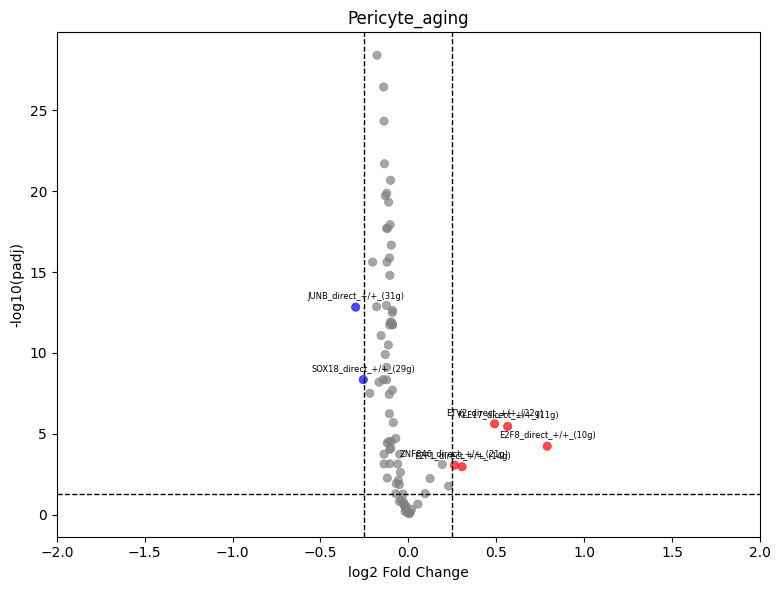

In [22]:
for cell_type in cell_types:
    cell_type_df = AUC_df[AUC_df['Cell_type'] == cell_type].copy()

    # produce sex volcano plot
    sex_res = regulon_diff_test(cell_type_df, group_col="sex", comparison="sex")
    title = cell_type + "_sex"
    plot_volcano(sex_res, top_n = 30, title = title)
    plt.savefig(plots_dir + cell_type + "_sex_differential_regulon_activity.pdf")

    # produce aging volcano plot
    aging_res = regulon_diff_test(cell_type_df, group_col="age_group", comparison="age")
    title = cell_type + "_aging"
    plot_volcano(aging_res, top_n = 20, title = title)
    plt.savefig(plots_dir + cell_type + "_aging_differential_regulon_activity.pdf")